In [33]:
import pandas as pd
import geopandas as gpd
import h3
import folium


import branca.colormap as cm
import matplotlib.pyplot as plt

import contextily as cx
from shapely.geometry import Polygon

In [34]:
df = pd.read_csv("movement.csv")

print(df.head())


  licencePlate car_type  vehicleTypeId  start_move_time    end_move_time  \
0      bn32098      car              2   7/22/2025 9:13   7/22/2025 9:17   
1      bn32098      car              2   7/22/2025 9:19   7/22/2025 9:23   
2      bn32098      car              2  7/22/2025 12:10  7/22/2025 14:24   
3      bn32098      car              2   7/23/2025 5:44  7/23/2025 15:46   
4      bn32098      car              2  7/23/2025 17:06  7/23/2025 17:20   

   start_lat  start_lon    end_lat    end_lon  start_zip  end_zip  \
0  55.658398  12.514628  55.658348  12.515684       2500     2500   
1  55.658348  12.515684  55.659286  12.519309       2500     1805   
2  55.659286  12.519309  55.677685  12.522237       1805     2000   
3  55.677685  12.522237  55.676945  12.520396       2000     2000   
4  55.676945  12.520396  55.655346  12.537441       2000     2450   

   start_area_name    end_area_name    move_duration  
0            Valby            Valby  0 days 00:04:00  
1            Valby

In [35]:
H3_Size = 8

df['start_h3'] = df.apply(
    lambda row: h3.latlng_to_cell(
        row['start_lat'],
        row['start_lon'],
        H3_Size
    ),
    axis=1
)

df['end_h3'] = df.apply(
    lambda row: h3.latlng_to_cell(
        row['end_lat'],
        row['end_lon'],
        H3_Size
    ),
    axis=1
)


In [36]:
demand = (
    df.groupby('start_h3').size().reset_index(name='demand_count')
)

supply = (
    df.groupby('end_h3').size().reset_index(name='supply_count')
)

demand = demand.rename(columns={'start_h3': 'h3_cell'})
supply = supply.rename(columns={'end_h3': 'h3_cell'})

gap_df = pd.merge(
    demand,
    supply,
    on='h3_cell',
    how='outer'
).fillna(0)

gap_df['gap_index'] = (
    gap_df['demand_count'] -
    gap_df['supply_count']
)


In [37]:
def h3_to_polygon(h):

    boundary = h3.cell_to_boundary(h)

    coords = [(lng, lat) for lat, lng in boundary]

    return Polygon(coords)

gap_df['geometry'] = gap_df['h3_cell'].apply(
    h3_to_polygon
)

gdf = gpd.GeoDataFrame(
    gap_df,
    geometry='geometry',
    crs='EPSG:4326'
)

In [38]:
gdf = gdf.cx[
    12.2:12.8,
    55.55:55.80
]

print("Copenhagen cells:", len(gdf))

Copenhagen cells: 356


In [39]:


m = folium.Map(
    location=[55.6761, 12.5683],
    zoom_start=11,
    tiles='CartoDB positron'
)


vmin = gdf['gap_index'].min()
vmax = gdf['gap_index'].max()


colormap = cm.LinearColormap(
    colors=['darkblue', 'lightcoral', 'darkred'],
    index=[vmin, 0, vmax],
    vmin=vmin,
    vmax=vmax,
    caption='Demand-Supply Gap (Red: High Demand, Blue: High Supply)'
)


def style(feature):
   
    gap = feature['properties']['gap_index']
    color = colormap(gap)
    return {
        'fillColor': color,
        'color': 'white',
        'weight': 0.5,
        'fillOpacity': 0.50
    }


folium.GeoJson(
    gdf,
    style_function=style,
    
).add_to(m)


colormap.add_to(m)

m.save("green_mobility_h3_map.html")

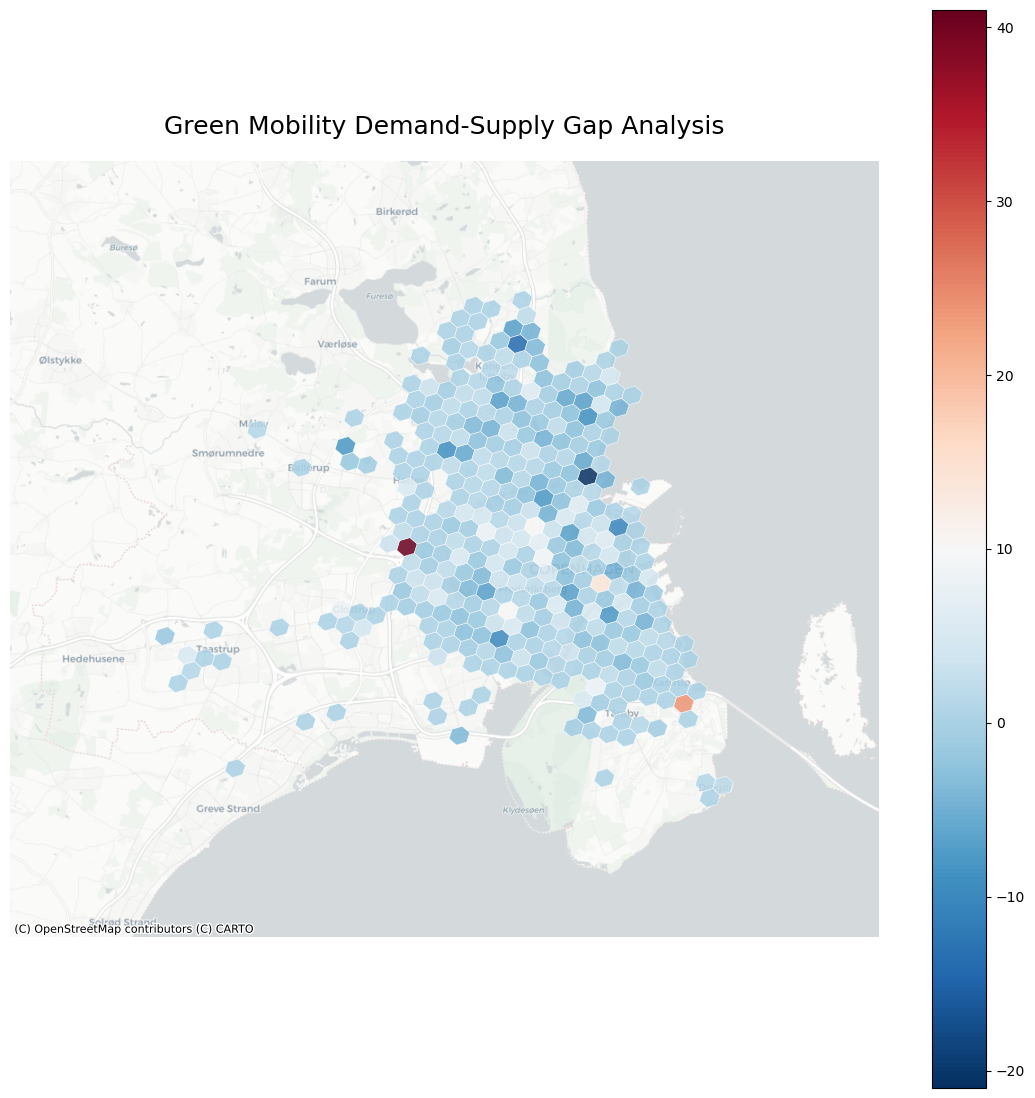

In [46]:
gdf_3857 = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 14))

gdf_3857.plot(
    ax=ax,
    column='gap_index',
    cmap='RdBu_r',
    edgecolor='white',
    linewidth=0.4,
    alpha=0.85,
    legend=True
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron,
    crs=gdf_3857.crs
)


minx, miny, maxx, maxy = gdf_3857.total_bounds

x_axis = (maxx - minx) * 0.25

y_axis = (maxy - miny) * 0.25

ax.set_xlim(minx - x_axis, maxx + x_axis)
ax.set_ylim(miny - y_axis, maxy + y_axis)

ax.set_axis_off()
ax.set_title(
    "Green Mobility Demand-Supply Gap Analysis",
    fontsize=18,
    pad=20
)

plt.savefig("green_mobility_h3_report.png")

plt.show()
